# 2.6 Métodos de remuestreo

Los datos tienen variabilidad natural. Cualquier estadístico que calculemos a partir de una muestra (una media, una correlación, una pendiente de regresión) hereda esa variabilidad.

Los **métodos de remuestreo** nos permiten medirla. En términos amplios, el remuestreo (*resampling*) es cualquier técnica en la que extraemos observaciones de una muestra repetidamente, recalculamos un estadístico en cada extracción y estudiamos la distribución de los resultados. Sus aplicaciones incluyen las pruebas de hipótesis, la propagación de incertidumbre y los intervalos de confianza.

La lección tiene tres niveles. El nivel 1 recorre tres técnicas básicas de remuestreo: aleatorización, *bootstrap* y Monte Carlo. El nivel 2 aplica el *bootstrap* a la inferencia de un modelo de regresión lineal, primero sobre datos GNSS sintéticos con respuesta conocida y luego sobre datos GNSS reales de la zona de subducción de Cascadia. El nivel 3 pasa al otro sentido de «remuestreo» — cambiar el muestreo de una señal: submuestrear sin *aliasing* (solapamiento espectral), interpolar huecos bajo una política explícita, agregar redes de estaciones irregulares, y el *bootstrap* por bloques para ruido correlacionado.

Primero, importe los módulos que necesitamos:

🖥️ [**Diapositivas — Sesión 06 (lun 12 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec06_sampling_resampling.html)

In [1]:
import os
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mlgeo_synth

**Una nota sobre los números aleatorios.** El código antiguo de NumPy siembra el estado aleatorio global con `np.random.seed(42)` y luego llama funciones como `np.random.normal`. El NumPy moderno lo reemplaza con un objeto generador explícito: `rng = np.random.default_rng(42)`. El generador lleva su propio estado, de modo que las distintas partes de un programa (o de un cuaderno) no interfieren entre sí a través de un global oculto. En este libro usamos el idioma del generador en todas partes. Fijar la semilla hace el cuaderno reproducible de principio a fin.

In [2]:
# One generator for the whole notebook, with a fixed seed for reproducibility.
rng = np.random.default_rng(42)
rng

Generator(PCG64) at 0x14F424820

## 1. Ejemplos de técnicas de remuestreo (Nivel 1)

### 1.1 Aleatorización

Dados dos conjuntos de datos, $A$ y $B$, y un parámetro, $x$, podemos reasignar aleatoriamente las observaciones a $A$ o a $B$, calcular algún estadístico (por ejemplo, $x_A - x_B$) y repetir, para construir una distribución de ese estadístico bajo la hipótesis nula de que las etiquetas de grupo no importan.

In [3]:
# We begin with two datasets, A and B
A = rng.normal(5, 2.5, 100)
B = rng.normal(5.5, 2.5, 100)

# We then calculate the means of each dataset
mean_A = np.mean(A)
mean_B = np.mean(B)

print(f'The means of A and B are {mean_A:.3f} and {mean_B:.3f}, respectively.')

# And, for the sake of illustration, also calculate the difference between these means
diff_means = mean_A - mean_B
print(f'The difference of means is {diff_means:.3f}.')

The means of A and B are 4.874 and 5.473, respectively.
The difference of means is -0.599.


Ahora remuestreamos.

In [4]:
# First, how many times do we want to resample?
number_runs = 10000

# Next, we create an array that will store the difference of means
array_of_diffs = np.zeros(number_runs)

# To ease computational burden, declare some variables:
# a combined list of A and B, and the length of A
combined = np.concatenate((A, B))
length_A = len(A)

En cada corrida barajamos los datos combinados, los dividimos en dos grupos nuevos con los tamaños originales y recalculamos la diferencia de medias.

In [5]:
for i in range(number_runs):
    # Shuffle the combined list. Note that shuffle works in place!
    rng.shuffle(combined)
    # Split the list into A and B, maintaining their original sizes.
    new_A = combined[0:length_A]
    new_B = combined[length_A:len(combined)]
    # Calculate and store a difference of means
    array_of_diffs[i] = np.mean(new_A) - np.mean(new_B)

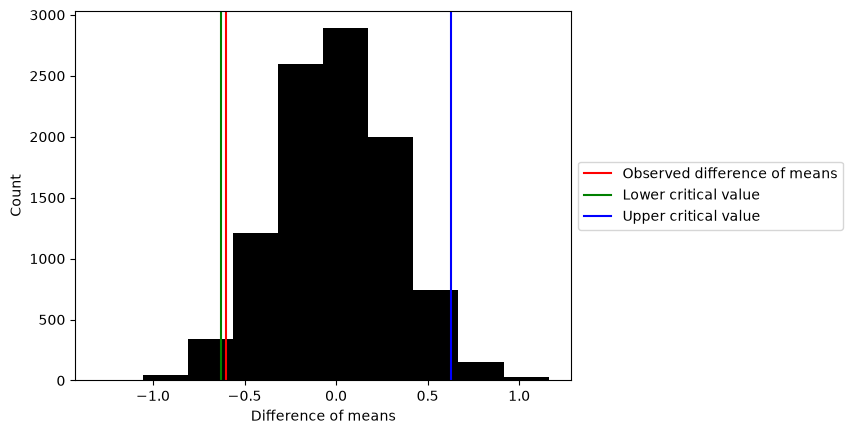

In [6]:
# Plot the array of diffs
plt.hist(array_of_diffs, color='black')

# Given an alpha of 0.05, can we accept or reject the null hypothesis of no difference in means?
alpha = 0.05
lower_critical_value = np.quantile(array_of_diffs, alpha / 2)
upper_critical_value = np.quantile(array_of_diffs, 1 - (alpha / 2))

# Plot the critical values and the observed value
plt.axvline(x=diff_means, color='r')
plt.axvline(x=lower_critical_value, color='g')
plt.axvline(x=upper_critical_value, color='b')
plt.xlabel('Difference of means')
plt.ylabel('Count')
plt.legend(['Observed difference of means', 'Lower critical value', 'Upper critical value'],
           loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### 1.2 Bootstrap

Al hacer *bootstrap*, usted extrae observaciones de una muestra repetidamente, **con reemplazo**. Cada remuestra de *bootstrap* tiene el **mismo tamaño que la muestra original**. Como la extracción es con reemplazo, una remuestra contendrá observaciones duplicadas y omitirá otras. La dispersión del estadístico a través de las remuestras estima la incertidumbre muestral de ese estadístico.

El *bootstrap* no hace supuestos fuertes sobre la distribución subyacente de los datos.

Primero creamos una «población verdadera» sintética de datos correlacionados con el método del generador ``multivariate_normal`` ([documentación aquí](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multivariate_normal.html)). La media de ambas variables es cero y su covarianza es -0.75.

In [7]:
# A population where two variables are strongly anticorrelated
correlated_data = rng.multivariate_normal([0, 0], [[1, -0.75], [-0.75, 1]], 1000)

Compruebe que los datos están efectivamente anticorrelacionados graficando una variable contra la otra.

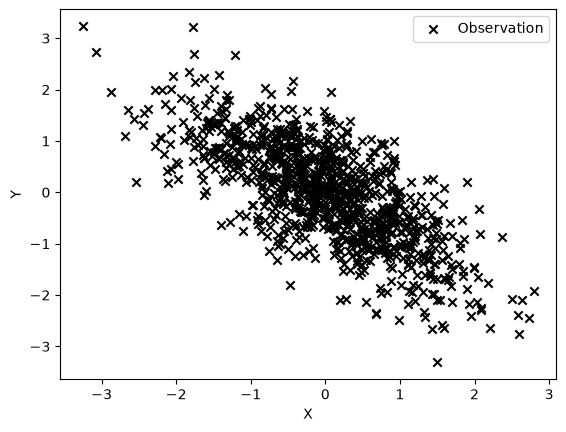

In [8]:
plt.scatter(correlated_data[:, 0], correlated_data[:, 1], marker='x', c='black')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['Observation'])
plt.show()

Verificamos que el [coeficiente de correlación](https://en.wikipedia.org/wiki/Correlation_coefficient) de Pearson está cerca de nuestro objetivo con la función de NumPy ``corrcoef``.

In [9]:
correlation_matrix = np.corrcoef(correlated_data[:, 0], correlated_data[:, 1])
print(f'The population correlation coefficient is {correlation_matrix[0, 1]:.3f}.')

The population correlation coefficient is -0.721.


En la práctica nunca observamos la población completa. Tomamos ahora un subconjunto pequeño de los datos --- piense en el subconjunto como *la muestra que de verdad recolectamos*.

The correlation coefficient of our sample is -0.619.


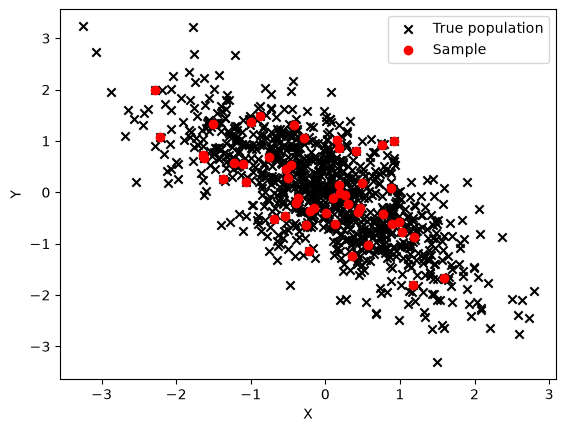

In [10]:
nsubset = 50
subset = rng.choice(correlated_data, size=nsubset, replace=False)

# Report the correlation coefficient of the sample
sample_corr = np.corrcoef(subset[:, 0], subset[:, 1])[0, 1]
print(f'The correlation coefficient of our sample is {sample_corr:.3f}.')

# Plot both the population and our sample
plt.scatter(correlated_data[:, 0], correlated_data[:, 1], marker='x', c='black')
plt.scatter(subset[:, 0], subset[:, 1], c='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['True population', 'Sample'])
plt.show()

Ahora hacemos *bootstrap*. Cada remuestra extrae `len(subset)` pares **de la muestra misma**, con reemplazo. El tamaño de la remuestra coincide con el de la muestra original: eso es lo que hace que la dispersión del estadístico remuestreado imite la variabilidad muestral de la estimación original.

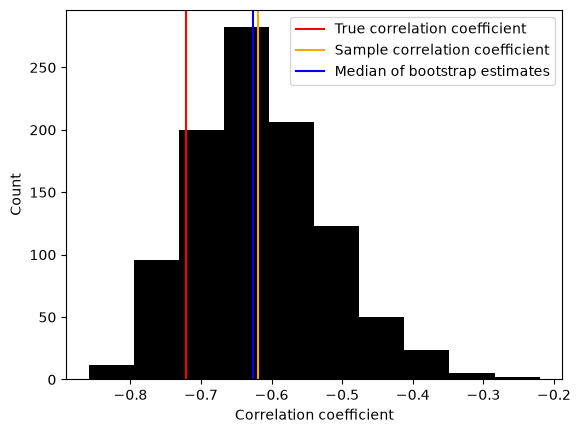

In [11]:
number_runs = 1000

# Array to record the correlation coefficient of each resample
corr_coef_collector = np.zeros(number_runs)

# The bootstrap resample size equals the original sample size.
length_sub = len(subset)

for i in range(number_runs):
    # Draw length_sub pairs from the sample, WITH REPLACEMENT
    new_pairs = rng.choice(subset, size=length_sub, replace=True)
    corr_coef_collector[i] = np.corrcoef(new_pairs[:, 0], new_pairs[:, 1])[0, 1]

# Plot the bootstrap distribution
plt.hist(corr_coef_collector, color='black')
plt.xlabel('Correlation coefficient')
plt.ylabel('Count')

plt.axvline(x=correlation_matrix[0, 1], color='red')
plt.axvline(x=sample_corr, color='orange')
plt.axvline(x=np.median(corr_coef_collector), color='blue')
plt.legend(['True correlation coefficient', 'Sample correlation coefficient',
            'Median of bootstrap estimates'])
plt.show()

La mediana de las estimaciones de *bootstrap* se ubica cerca del coeficiente de correlación de la *muestra*, no del valor verdadero de la población. El *bootstrap* no puede corregir el sesgo de una muestra pequeña; cuantifica la incertidumbre alrededor de la estimación que usted tiene.

¿Qué pasa si aumenta el tamaño de la muestra original?

#### ¿Y si el tamaño de la remuestra difiere del tamaño de la muestra?

El *bootstrap* se define con un tamaño de remuestra igual al tamaño de la muestra. Como experimento, rompemos esa regla a propósito y variamos el tamaño de la remuestra. Observe la dispersión de la distribución de *bootstrap*.

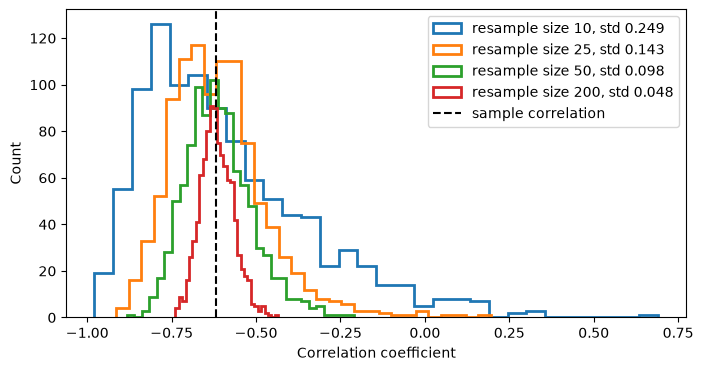

In [12]:
resample_sizes = [10, 25, 50, 200]  # 50 is the actual sample size

fig, ax = plt.subplots(figsize=(8, 4))
for m in resample_sizes:
    stats_m = np.zeros(number_runs)
    for i in range(number_runs):
        new_pairs = rng.choice(subset, size=m, replace=True)
        stats_m[i] = np.corrcoef(new_pairs[:, 0], new_pairs[:, 1])[0, 1]
    ax.hist(stats_m, bins=30, histtype='step', lw=2,
            label=f'resample size {m}, std {np.std(stats_m):.3f}')

ax.axvline(sample_corr, color='k', ls='--', label='sample correlation')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('Count')
ax.legend()
plt.show()

Las remuestras más pequeñas producen una dispersión más amplia del estadístico: una correlación estimada con 10 pares es más ruidosa que una estimada con 50. Las remuestras más grandes que la muestra producen una dispersión demasiado estrecha, que subestima la incertidumbre verdadera. Solo una remuestra del mismo tamaño que la muestra original reproduce la variabilidad muestral de la estimación que usted realmente hizo.

### 1.3 Monte Carlo

Bautizados por el casino de Mónaco, los métodos de Monte Carlo consisten en *simular datos nuevos* a partir de un modelo estadístico conocido (¡o supuesto!). A diferencia de los dos ejemplos anteriores, no extraemos de una muestra existente.

Las técnicas de Monte Carlo tienen muchas aplicaciones: evaluación probabilista de riesgos, propagación de incertidumbre en modelos y evaluación de sistemas demasiado complicados para un análisis en forma cerrada.

Aquí demostramos el muestreo de Monte Carlo estimando $\pi$.

Partimos de una idea central: la razón entre el área de un círculo y el área del cuadrado que lo circunscribe es $\pi/4$.

Imaginamos entonces un círculo de radio 1 inscrito en un cuadrado cuyos lados van de -1 a 1.

In [13]:
# We draw (x, y) points from a *uniform* distribution and determine whether each point
# sits within the circle. Every point lands in the square; only some land in the circle.
in_circle = np.empty([0, 2])
in_square = np.empty([0, 2])

# Generate the samples. Keep the number small at first.
number_runs = 50

for _ in range(number_runs):  # note that _ avoids creating a loop variable we never use
    x = rng.uniform(low=-1, high=1)
    y = rng.uniform(low=-1, high=1)
    # How far is this point from the origin?
    origin_dist = x**2 + y**2
    # If origin_dist is less than 1, the point is inside the circle
    if origin_dist <= 1:
        in_circle = np.append(in_circle, [[x, y]], axis=0)
    in_square = np.append(in_square, [[x, y]], axis=0)

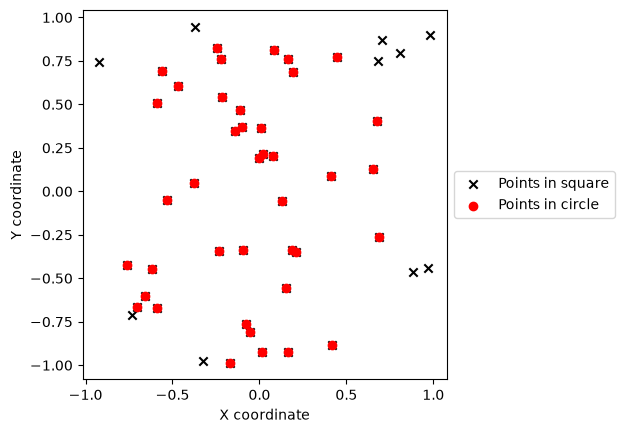

In [14]:
# Visualize what we just did
plt.scatter(in_square[:, 0], in_square[:, 1], marker='x', c='black')
plt.scatter(in_circle[:, 0], in_circle[:, 1], marker='o', c='red')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.legend(['Points in square', 'Points in circle'], loc='center left', bbox_to_anchor=(1, 0.5))
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()

Ahora estimamos $\pi$ usando los conteos de puntos dentro del círculo y dentro del cuadrado como aproximaciones de sus áreas.

In [15]:
pi_est = 4 * (len(in_circle) / len(in_square))
print(f'We estimate the value of pi to be: {pi_est}.')

We estimate the value of pi to be: 3.2.


Con pocas corridas no obtenemos una buena respuesta.

Un enfoque de Monte Carlo necesita más corridas para **converger**.

Explore cómo cambia su estimación de $\pi$ (y cómo converge su cálculo) al cambiar el número de corridas.

## 2. Remuestreo para una inferencia robusta de modelos (Nivel 2)

El plan: ajustar una tendencia lineal a datos de posición GNSS y usar el *bootstrap* para poner una incertidumbre sobre la pendiente (la velocidad de la placa). Empezamos con una serie **sintética**, donde conocemos la velocidad verdadera, para poder comparar la distribución de *bootstrap* con la respuesta correcta. Luego repetimos el análisis con datos **reales** de la estación P395, en el noroeste del Pacífico estadounidense.

### 2.1 Serie GNSS sintética con velocidad conocida

La función auxiliar `mlgeo_synth.gnss_series` construye una serie sintética de desplazamiento GNSS diario con una verdad de referencia conocida: una tendencia lineal, ciclos estacionales y ruido realista (blanco, *flicker* y caminata aleatoria). Fijamos la velocidad verdadera en 12 mm/año.

In [16]:
true_velocity = 12.0  # mm/yr, our ground truth

gnss = mlgeo_synth.gnss_series(n_years=10, velocity_mm_yr=true_velocity, seed=42)
gnss.head()

,date,disp_mm,trend_mm,seasonal_mm,eq_mm
0,2015-01-01,-2.651412,0.000000,-2.591412,0.0
1,2015-01-02,-3.522117,0.032854,-2.615349,0.0
2,2015-01-03,-3.734687,0.065708,-2.638816,0.0
3,2015-01-04,-5.674045,0.098563,-2.661778,0.0
4,2015-01-05,-3.430546,0.131417,-2.684198,0.0


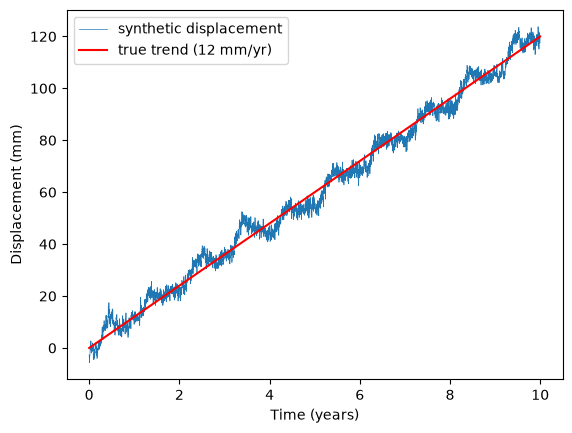

In [17]:
# Time in years since the first sample
t_syn = (gnss['date'] - gnss['date'].iloc[0]).dt.days / 365.25
d_syn = gnss['disp_mm']

plt.plot(t_syn, d_syn, lw=0.5, label='synthetic displacement')
plt.plot(t_syn, gnss['trend_mm'], 'r', label='true trend (12 mm/yr)')
plt.xlabel('Time (years)')
plt.ylabel('Displacement (mm)')
plt.legend()
plt.show()

Ajuste una línea recta con `scipy.stats.linregress`. La pendiente es nuestra estimación de la velocidad.

In [18]:
from scipy import stats

fit = stats.linregress(t_syn, d_syn)
print(f'Estimated velocity: {fit.slope:.3f} mm/yr (true value: {true_velocity} mm/yr)')

Estimated velocity: 11.838 mm/yr (true value: 12.0 mm/yr)


La estimación puntual está cerca de la verdad, pero ¿cuánta confianza deberíamos tener? *Bootstrap*: remuestree los pares (tiempo, desplazamiento) con reemplazo --- con un tamaño de remuestra igual a la longitud de los datos ---, reajuste la línea cada vez y recolecte las pendientes.

Bootstrap mean velocity: 11.838 mm/yr, standard deviation: 0.019 mm/yr


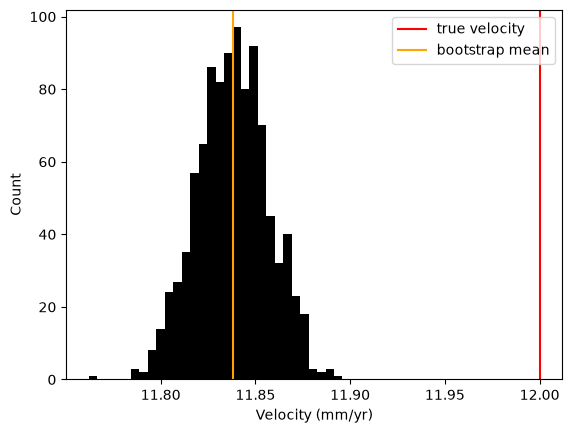

In [19]:
k = 1000
n_syn = len(t_syn)
t_arr = t_syn.to_numpy()
d_arr = d_syn.to_numpy()

vel_syn = np.zeros(k)
for j in range(k):
    ii = rng.integers(0, n_syn, size=n_syn)  # indices drawn with replacement
    vel_syn[j] = stats.linregress(t_arr[ii], d_arr[ii]).slope

print(f'Bootstrap mean velocity: {np.mean(vel_syn):.3f} mm/yr, '
      f'standard deviation: {np.std(vel_syn):.3f} mm/yr')

plt.hist(vel_syn, bins=30, color='black')
plt.axvline(true_velocity, color='red', label='true velocity')
plt.axvline(np.mean(vel_syn), color='orange', label='bootstrap mean')
plt.xlabel('Velocity (mm/yr)')
plt.ylabel('Count')
plt.legend()
plt.show()

Dos cosas para notar.

Primero, la distribución de *bootstrap* está centrada en la pendiente *estimada*, no en la verdad. El *bootstrap* cuantifica la variabilidad del estimador; no puede eliminar el desfase entre la estimación y la velocidad verdadera que produjo esta realización particular del ruido.

Segundo, la distribución es muy estrecha --- y la velocidad verdadera queda a varias desviaciones estándar de *bootstrap* de su centro. La barra de error es demasiado pequeña. La razón: remuestrear pares trata los residuos como independientes, pero el ruido GNSS está correlacionado en el tiempo (*flicker* y caminata aleatoria). El *bootstrap* de pares, por lo tanto, *subestima* la incertidumbre verdadera. Esquemas más avanzados (el *bootstrap* por bloques) remuestrean fragmentos contiguos de la serie para preservar la correlación. Tener la verdad de referencia es lo que expuso esto: con datos reales solamente, el histograma estrecho habría parecido tranquilizador.

### 2.2 Movimiento de placas a partir de datos geodésicos reales

Ahora, lo real. Usamos una serie de tiempo GNSS de la estación P395, en el noroeste del Pacífico estadounidense, y estimamos el movimiento de largo plazo debido a la zona de subducción de Cascadia.

Descargamos la serie de tiempo del [centro de datos](http://geodesy.unr.edu/NGLStationPages/gpsnetmap/GPSNetMap.html) de la University of Nevada, Reno — el mismo archivo global del que la lección [1.7](../Chapter1-GettingStarted/1.7_get_geodetic_gnss.ipynb) extrajo una estación de TLALOCNet en México. El archivo `tenv3` está delimitado por espacios en blanco, con una línea de encabezado. Las columnas que necesitamos son el año decimal (`yyyy.yyyy`) y las posiciones este, norte y arriba en metros (`__east(m)`, `_north(m)`, `____up(m)`).

In [20]:
sta = "P395"
url = f"https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{sta}.tenv3"
print(url)

os.makedirs('data', exist_ok=True)
fname = f'data/{sta}.tenv3'
r = requests.get(url, timeout=60)
r.raise_for_status()
with open(fname, 'wb') as f:
    f.write(r.content)

# Whitespace-delimited file; the first line is the header.
df = pd.read_csv(fname, sep=r'\s+')
df.head()

https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/P395.tenv3


,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,P395,06JAN25,2006.0671,53760,1359,3,-123.9,3347,0.560065,4987420,...,0.0083,0.000748,0.001125,0.003637,-0.053526,0.039949,-0.344025,45.022279,-123.857527,53.03951
1,P395,06JAN26,2006.0698,53761,1359,4,-123.9,3347,0.560733,4987420,...,0.0083,0.000740,0.001135,0.003557,-0.030311,0.021842,-0.308583,45.022279,-123.857527,53.03502
2,P395,06JAN27,2006.0726,53762,1359,5,-123.9,3347,0.560999,4987420,...,0.0083,0.000735,0.001120,0.003583,-0.023363,0.042888,-0.330909,45.022279,-123.857527,53.04103
3,P395,06JAN28,2006.0753,53763,1359,6,-123.9,3347,0.560352,4987420,...,0.0083,0.000756,0.001132,0.003778,-0.024996,0.024686,-0.365856,45.022279,-123.857527,53.04785
4,P395,06JAN29,2006.0780,53764,1360,0,-123.9,3347,0.560269,4987420,...,0.0083,0.000738,0.001132,0.003582,-0.041592,0.058166,-0.318254,45.022279,-123.857527,53.03961


In [21]:
# Keep only the columns we need and give them simpler names.
df = df[['yyyy.yyyy', '__east(m)', '_north(m)', '____up(m)']].rename(
    columns={'yyyy.yyyy': 'decimal year',
             '__east(m)': 'delta e (m)',
             '_north(m)': 'delta n (m)',
             '____up(m)': 'delta v (m)'})

# Drop rows with missing values. dropna returns a new frame: assign the result.
df = df.dropna()
df.head()

,decimal year,delta e (m),delta n (m),delta v (m)
0,2006.0671,0.560065,0.310612,0.039514
1,2006.0698,0.560733,0.309070,0.035025
2,2006.0726,0.560999,0.311102,0.041026
3,2006.0753,0.560352,0.308281,0.047853
4,2006.0780,0.560269,0.310305,0.039609


In [22]:
# Reference each component to the first epoch so positions start at zero.
df['new delta e (m)'] = df['delta e (m)'] - df['delta e (m)'].values[0]
df['new delta n (m)'] = df['delta n (m)'] - df['delta n (m)'].values[0]
df['new delta v (m)'] = df['delta v (m)'] - df['delta v (m)'].values[0]
df.head()

,decimal year,delta e (m),delta n (m),delta v (m),new delta e (m),new delta n (m),new delta v (m)
0,2006.0671,0.560065,0.310612,0.039514,0.000000,0.000000,0.000000
1,2006.0698,0.560733,0.309070,0.035025,0.000668,-0.001542,-0.004489
2,2006.0726,0.560999,0.311102,0.041026,0.000934,0.000490,0.001512
3,2006.0753,0.560352,0.308281,0.047853,0.000287,-0.002331,0.008339
4,2006.0780,0.560269,0.310305,0.039609,0.000204,-0.000307,0.000095


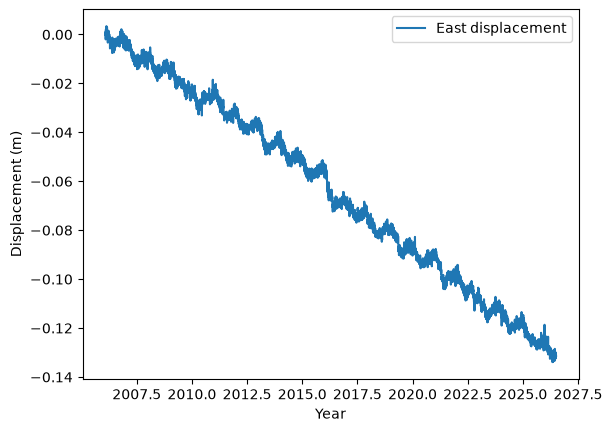

In [23]:
plt.plot(df['decimal year'], df['new delta e (m)'], label='East displacement')
plt.xlabel('Year')
plt.ylabel('Displacement (m)')
plt.legend()
plt.show()

### 2.3 Regresión lineal

Hay una **tendencia lineal** limpia en los datos de posición horizontal. Podemos ajustar los datos con:

$E(t) = V_e t + u_e,$\
$N(t) = V_n t + u_n,$

donde $t$ es el tiempo. Hacemos una regresión de los datos para encontrar los coeficientes $V_e$, $u_e$, $V_n$, $u_n$. Los desplazamientos son mayormente hacia el oeste, así que en este ejercicio nos concentramos en la componente este $E(t)$. Los coeficientes $u_e$ y $u_n$ son las ordenadas al origen en $t=0$. Aquí no son cero porque $t$ comienza en 2006. Los coeficientes $V_e$ y $V_n$ tienen dimensión de velocidad:

$V_e \sim E(t) / t$, $V_n \sim N(t) / t$,

así que este ejemplo nos permite discutir una **regresión lineal** simple y el remuestreo. Usamos tanto una función de SciPy como una de scikit-learn.

Para medir el desempeño del ajuste, medimos cuánto se reduce la varianza al ajustar los datos (los puntos dispersos) contra el modelo. La varianza es:

$\text{Var}(x) = 1/n \sum_{i=1}^n (x_i-\hat{x})^2$,

donde $\hat{x}$ es la media de $x$. Al ajustar la regresión, predecimos los valores $x_{pred}$. Los residuos son las diferencias entre los datos y los valores predichos: $e = x - x_{pred}$. El $R^2$ o <i>coeficiente de determinación</i> es:

$R^2 = 1 - \text{Var}(x-x_{pred}) /\text{Var}(x) = 1 - \text{Var}(e) /\text{Var}(x)$

Cuanto menor es el error, «mejor» es el ajuste (¡más adelante discutiremos que un ajuste puede ser demasiado bueno!) y más cerca de uno está el $R^2$.

In [24]:
# Linear regression: displacement = velocity * time + intercept, East component.
Ve, intercept, r_value, p_value, std_err = stats.linregress(df['decimal year'],
                                                            df['new delta e (m)'])
print(sta, "overall plate motion there", Ve, 'm/year')
print("parameters: correlation coefficient %4.2f, P-value %4.2f, standard error of the slope %g"
      % (r_value, p_value, std_err))

P395 overall plate motion there -0.006540884541421708 m/year
parameters: correlation coefficient -1.00, P-value 0.00, standard error of the slope 5.78311e-06


También podemos usar el paquete ``scikit-learn``:

Coefficient / velocity eastward (m/year):  -0.00654088454142171


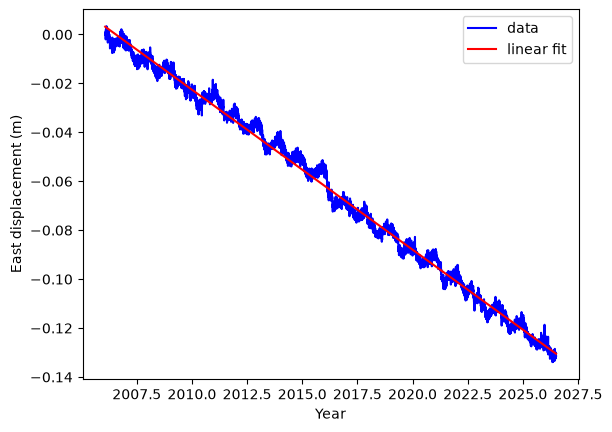

In [25]:
from sklearn.linear_model import LinearRegression

# Convert the data into numpy arrays. Reshaping to (n, 1) is required by scikit-learn.
E = np.asarray(df['new delta e (m)']).reshape(-1, 1)
t = np.asarray(df['decimal year']).reshape(-1, 1)

# Perform the linear regression on the entire available data
regr = LinearRegression()
regr.fit(t, E)
Epred = regr.predict(t)

# The coefficients
print('Coefficient / velocity eastward (m/year): ', regr.coef_[0][0])

# Plot the data and the fit
plt.plot(t, E, 'b', label='data')
plt.plot(t, Epred, 'r', label='linear fit')
plt.xlabel('Year')
plt.ylabel('East displacement (m)')
plt.legend()
plt.show()

Para evaluar los errores del ajuste del modelo con ``sklearn``, usamos las funciones siguientes:

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error
print('Mean squared error (m^2): %.6f' % mean_squared_error(E, Epred))
# The coefficient of determination: 1 is the perfect prediction
print('Coefficient of determination: %.2f' % r2_score(E, Epred))

Mean squared error (m^2): 0.000009
Coefficient of determination: 0.99


### 2.4 Bootstrap de la velocidad

Ahora usamos el *bootstrap* para estimar la pendiente de la regresión sobre muchos conjuntos de datos remuestreados, exactamente como lo hicimos con la serie sintética.

Scikit-learn provee ``resample`` en el módulo ``utils``. Asegúrese de usar ``replace=True`` y un tamaño de remuestra igual a la longitud de los datos (el valor por defecto). Para resultados reproducibles, puede pasar un ``random_state`` fijo. El *bootstrap* suele repetirse muchas veces (a diferencia de la validación cruzada K-fold, el esquema de evaluación de modelos del capítulo 3.8, que divide los datos en un número fijo de pliegues sin traslape).

mean of the velocity estimates -0.00654102 m/yr and standard deviation 5.34869e-06 m/yr


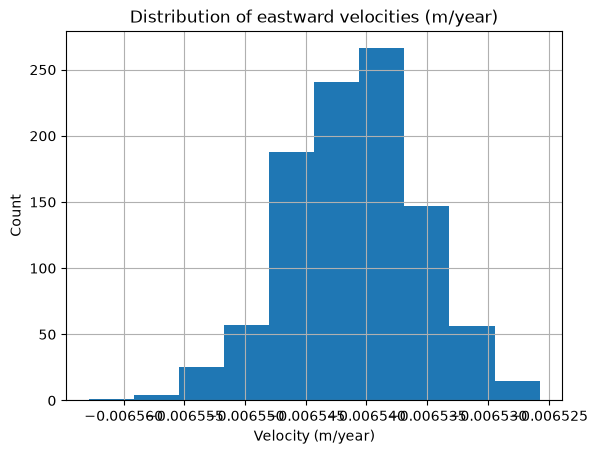

In [27]:
from sklearn.utils import resample

k = 1000
vel = np.zeros(k)  # initialize a vector to store the regression slopes
for i in range(k):
    ii = resample(np.arange(len(E)), replace=True, n_samples=len(E),
                  random_state=i)  # new indices
    E_b, t_b = E[ii], t[ii]
    # Fit the resampled data
    regr = LinearRegression()
    regr.fit(t_b, E_b)
    vel[i] = regr.coef_[0][0]

# The data shows a clear trend, so the slope estimates are close to each other:
print("mean of the velocity estimates %g m/yr and standard deviation %g m/yr"
      % (np.mean(vel), np.std(vel)))

plt.hist(vel, 10)
plt.title('Distribution of eastward velocities (m/year)')
plt.xlabel('Velocity (m/year)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

La dispersión de *bootstrap* en los datos reales es pequeña porque la tendencia domina sobre el ruido, igual que en el caso sintético. Aplica la misma salvedad: el ruido GNSS está correlacionado en el tiempo, así que trate esta barra de error como una cota inferior.

## 3. Remuestreo de señales y datos irregulares (Nivel 3)

Las secciones 1 y 2 usaron «remuestreo» en el sentido estadístico: volver a extraer de una muestra para medir la incertidumbre. La palabra tiene un segundo sentido que todo flujo de sensores impone tarde o temprano: **cambiar el muestreo de una serie de tiempo** — submuestrear un registro de alta tasa, rellenar o negarse a rellenar huecos, y llevar observaciones irregulares a una malla regular. Ambos sentidos comparten una trampa: hechos con ingenuidad, fabrican señal que nunca se midió.

Esta sección trabaja tres flujos de datos que cubren la mayor parte de lo que encontrará en la práctica:

* una **serie regular de alta tasa** (un mareógrafo horario) que submuestreamos a valores diarios;
* una **serie regular con interrupciones** (un registro GNSS diario con huecos) que interpolamos bajo una política de huecos explícita;
* un **flujo de puntos disperso e irregular** (una red de pozos de agua subterránea de varias décadas) donde nada en el muestreo es regular y las decisiones de agregación dominan el resultado.

Cada uno es sintético con verdad de referencia conocida, así que cada reparación recibe calificación. Cerramos volviendo a la barra de error demasiado estrecha del *bootstrap* de la sección 2.1 y la corregimos con un *bootstrap* por bloques.

### 3.1 Submuestreo y aliasing

El submuestreo parece inofensivo: conservar una de cada $q$ muestras y descartar el resto. No lo es. Una serie muestreada con intervalo $\Delta t$ solo puede representar frecuencias hasta la **frecuencia de Nyquist** $f_N = 1/(2\Delta t)$. Cualquier señal por encima del *nuevo* Nyquist no desaparece al submuestrear — se **pliega** (*aliasing*, solapamiento espectral) hacia una frecuencia más baja, disfrazada de una señal que nunca existió.

El banco de pruebas limpio es un mareógrafo. `mlgeo_synth.tide_gauge_series` genera nivel del mar horario a partir de cuatro componentes astronómicas más una tendencia, un ciclo estacional y ruido meteorológico — y devuelve las componentes de marea como verdad de referencia. Supongamos que queremos una serie *diaria* de nivel del mar para estudiar la señal lenta (submareal).

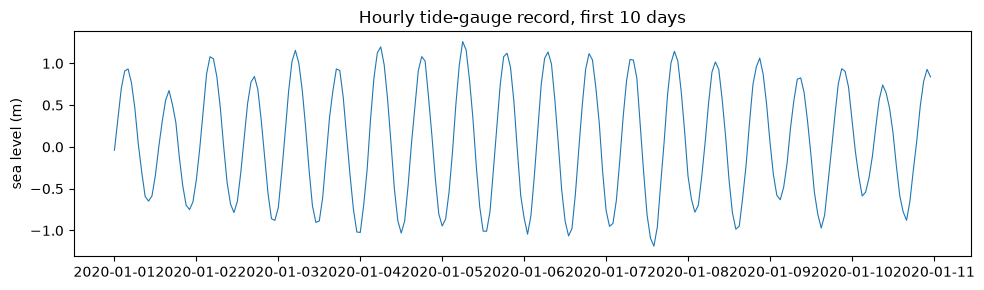

,period_h,amplitude_m,phase_rad
constituent,,,
M2,12.420601,0.80,4.862909
S2,12.000000,0.30,2.757555
K1,23.934470,0.15,5.394730
O1,25.819342,0.10,4.381693


In [28]:
# Six months of hourly sea level
tide, tide_truth = mlgeo_synth.tide_gauge_series(n_days=180, seed=42)
sl = tide.set_index('time')['sea_level_m']

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sl.iloc[:24 * 10], lw=0.8)
ax.set_ylabel('sea level (m)')
ax.set_title('Hourly tide-gauge record, first 10 days')
plt.tight_layout()
plt.show()

tide_truth['constituents']

La componente dominante es M2, la marea semidiurna lunar principal, con un periodo de 12.42 horas — una frecuencia de 1.93 ciclos por día. Una serie diaria tiene una frecuencia de Nyquist de 0.5 ciclos por día, así que toda la marea vive *por encima* del nuevo Nyquist. Si conservamos una muestra por día (digamos, la lectura de medianoche), M2 se pliega a $|1.93 - 2| = 0.068$ ciclos por día: una oscilación espuria con un **periodo de 14.8 días** y la amplitud de marea completa de ~0.8 m.

La corrección es la regla que todo submuestreo debe seguir: **primero filtre pasabajas por debajo de la nueva frecuencia de Nyquist, y luego submuestree.** Una *media* diaria es un filtro pasabajas rudimentario (una ventana rectangular de 24 horas) y ya suprime la mayor parte de la marea; `scipy.signal.decimate` aplica un filtro anti-alias apropiado antes de submuestrear. Calificamos las tres versiones contra el nivel del mar diario sin marea verdadero, que podemos calcular con exactitud porque el generador devolvió la marea como una columna aparte.

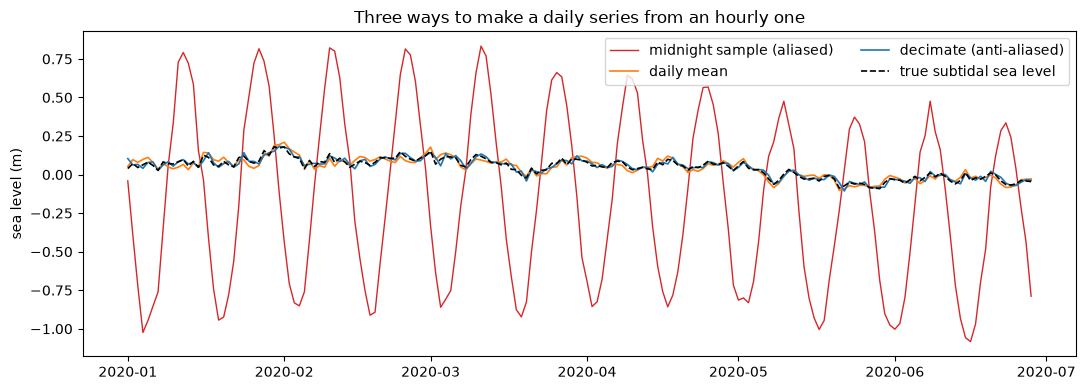

midnight sample  RMS error vs true subtidal signal: 0.589 m
daily mean       RMS error vs true subtidal signal: 0.020 m
decimate         RMS error vs true subtidal signal: 0.017 m


In [29]:
from scipy import signal

# Ground truth: the daily mean of the tide-free sea level
subtidal = (tide.set_index('time')['sea_level_m']
            - tide.set_index('time')['tide_m']).resample('D').mean()

# WRONG: keep one sample per day (midnight), discard the rest
naive = sl.iloc[::24]

# Crude anti-alias: daily mean (a 24-h boxcar low-pass, then subsample)
daily_mean = sl.resample('D').mean()

# Proper anti-alias: decimate in two stages (scipy recommends factors <= 13)
dec = signal.decimate(signal.decimate(sl.to_numpy(), 4, ftype='fir', zero_phase=True),
                      6, ftype='fir', zero_phase=True)
dec = pd.Series(dec, index=sl.index[::24])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(naive, color='tab:red', lw=1, label='midnight sample (aliased)')
ax.plot(daily_mean, color='tab:orange', lw=1.2, label='daily mean')
ax.plot(dec, color='tab:blue', lw=1.2, label='decimate (anti-aliased)')
ax.plot(subtidal, 'k--', lw=1.2, label='true subtidal sea level')
ax.set_ylabel('sea level (m)')
ax.legend(ncols=2)
ax.set_title('Three ways to make a daily series from an hourly one')
plt.tight_layout()
plt.show()

for name, s_daily in [('midnight sample', naive), ('daily mean', daily_mean),
                      ('decimate', dec)]:
    err = (s_daily - subtidal).dropna()
    print(f'{name:16s} RMS error vs true subtidal signal: {np.sqrt((err**2).mean()):.3f} m')

Las muestras de medianoche llevan una oscilación de ~15 días y de más de medio metro que no existe en el océano submareal — esa es la marea M2 plegada por *aliasing*, y su error RMS es treinta veces mayor que el de cualquiera de las dos versiones con anti-alias. Nada en la serie ingenua *parece* incorrecto; la ondulación quincenal hasta se asemeja a una señal oceánica plausible. Eso es lo que hace peligroso al *aliasing*: el artefacto viene vestido de física. La altimetría satelital convive exactamente con este problema — la órbita de TOPEX/Jason muestrea cada punto cada ~10 días, plegando M2 en una señal de 62 días que debe modelarse y removerse.

`pandas.DataFrame.resample('D').mean()` — la línea única a la que recurrirá más a menudo — ya es un filtro anti-alias decente para este propósito. La regla para internalizar: **antes de reducir la tasa de muestreo, pregunte qué vive por encima de la nueva frecuencia de Nyquist y remuévalo.** Si la respuesta es «nada», dígalo explícitamente en su ficha de datos.

### 3.2 Huecos: interpolar es una decisión, no un valor por defecto

Los flujos diarios reales llegan con interrupciones. `mlgeo_synth.degrade_series` inyecta huecos en la serie GNSS sintética de la sección 2.1 — más una interrupción de 150 días que colocamos, deliberadamente, sobre un sismo (una estación fuera de servicio por la misma sacudida que debía registrar no es una hipótesis — piense en una red costera durante un gran sismo de subducción). La función devuelve la verdad sin censura, así que podemos calificar cualquier reparación.

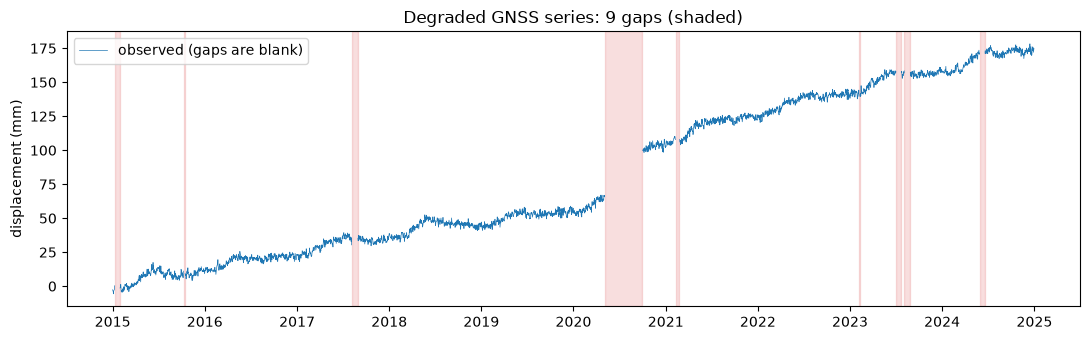

In [30]:
# The same 10-yr, 12 mm/yr station, now with a coseismic step at day 2000
gnss_eq = mlgeo_synth.gnss_series(n_years=10, velocity_mm_yr=12.0,
                                  eq_day=2000, coseismic_mm=25.0, seed=42)

# Degrade it: an imposed 150-day outage swallowing the earthquake, plus 8 random gaps
broken, truth = mlgeo_synth.degrade_series(gnss_eq, gap_windows=[(1950, 2100)],
                                           n_random_gaps=8, gap_days=(2, 25), seed=13)

s = broken.set_index('date')['disp_mm']
clean = pd.Series(truth['clean'].to_numpy(), index=s.index)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(s, lw=0.5, label='observed (gaps are blank)')
for s0, e0 in truth['gap_windows']:
    ax.axvspan(s.index[s0], s.index[e0 - 1], color='tab:red', alpha=0.15)
ax.set_ylabel('displacement (mm)')
ax.legend()
ax.set_title(f'Degraded GNSS series: {len(truth["gap_windows"])} gaps (shaded)')
plt.tight_layout()
plt.show()

La línea única tentadora es `s.interpolate()`: unir los puntos a través de cada hueco. Antes de confiar en ella, mida lo que cuesta — interpole *todo* y compare contra la verdad, hueco por hueco.

In [31]:
filled_all = s.interpolate(method='time')

noise_std = (gnss_eq['disp_mm'] - gnss_eq['trend_mm'] - gnss_eq['seasonal_mm']
             - gnss_eq['eq_mm']).std()
print(f'daily noise level of this series: {noise_std:.2f} mm RMS\n')

print('gap length   RMS error of linear interpolation inside the gap')
for s0, e0 in sorted(truth['gap_windows'], key=lambda w: w[1] - w[0]):
    idx = s.index[s0:e0]
    rms = np.sqrt(((filled_all - clean)[idx] ** 2).mean())
    print(f'{e0 - s0:7d} d   {rms:5.2f} mm')

daily noise level of this series: 2.41 mm RMS

gap length   RMS error of linear interpolation inside the gap
      3 d    0.74 mm
      6 d    1.84 mm
     16 d    1.60 mm
     20 d    1.35 mm
     21 d    1.87 mm
     21 d    1.79 mm
     23 d    1.70 mm
     24 d    2.37 mm
    150 d    8.09 mm


Los huecos cortos se interpolan con un error igual o menor que el nivel de ruido: en unos pocos días la tendencia y el ciclo estacional apenas se mueven, así que una línea recta es tan buena como los datos. El hueco de 150 días es distinto — su error es más de tres veces el ruido, porque la interpolación trazó una rampa suave a través de un escalón cosísmico de 25 mm que no tenía manera de conocer. Los valores rellenados no son ruidosos; están *confiadamente equivocados*, y cualquier código posterior (un ajuste de tendencia, una ventana de características para ML) los tratará como mediciones.

Así que enunciamos una **política de huecos** como decisión explícita y no como valor por defecto de una biblioteca:

* **Interpolar los huecos de 10 días o menos.** Justificación, a partir de la tabla de arriba: a 12 mm/año y con una amplitud estacional de ~3 mm, la señal determinista se mueve bastante menos que el nivel de ruido de 2.4 mm en 10 días, así que el error de interpolación queda acotado por el ruido. El umbral lo fijan las tasas de señal de *esta estación* — una estación con movimiento más rápido o vaivenes estacionales mayores merece un umbral más corto, y el umbral pertenece a la ficha de datos.
* **Enmascarar los huecos más largos como faltantes.** Un `NaN` es una declaración honesta: no sabemos qué pasó ahí adentro — y en este registro, algo pasó.

samples filled (short gaps): 9,  RMS error 1.56 mm (noise level 2.41 mm)
samples masked (long gaps):  275,  RMS error if we had interpolated them: 6.10 mm


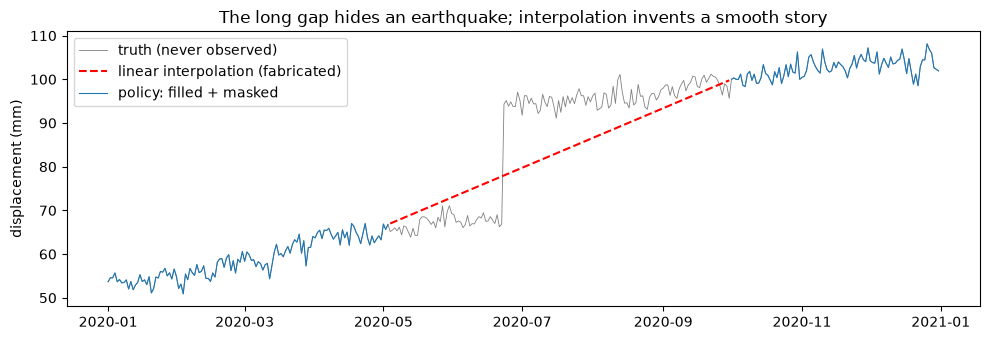

In [32]:
max_gap_days = 10  # the decision, justified above

# Length of the gap each missing sample belongs to
isna = s.isna()
gap_id = (isna != isna.shift()).cumsum()
gap_len = isna.groupby(gap_id).transform('sum').where(isna, 0)

# Fill short gaps, keep long gaps as NaN
repaired = filled_all.where(~(isna & (gap_len > max_gap_days)))

short_filled = isna & (gap_len <= max_gap_days)
long_masked = isna & (gap_len > max_gap_days)
rms_short = np.sqrt(((repaired - clean)[short_filled] ** 2).mean())
rms_if_filled = np.sqrt(((filled_all - clean)[long_masked] ** 2).mean())

print(f'samples filled (short gaps): {short_filled.sum()},  RMS error {rms_short:.2f} mm '
      f'(noise level {noise_std:.2f} mm)')
print(f'samples masked (long gaps):  {long_masked.sum()},  RMS error if we had '
      f'interpolated them: {rms_if_filled:.2f} mm')

# Zoom on the long gap: what interpolation would have fabricated
zoom = slice('2020-01-01', '2020-12-31')
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(clean[zoom], color='gray', lw=0.6, label='truth (never observed)')
ax.plot(filled_all[zoom].where(long_masked[zoom]), 'r--', lw=1.5,
        label='linear interpolation (fabricated)')
ax.plot(repaired[zoom], lw=0.8, color='tab:blue', label='policy: filled + masked')
ax.set_ylabel('displacement (mm)')
ax.legend()
ax.set_title('The long gap hides an earthquake; interpolation invents a smooth story')
plt.tight_layout()
plt.show()

El resultado calificado: la interpolación de huecos cortos cuesta menos que el ruido, y la máscara se niega a inventar los 150 días que nunca vimos. Cuando esta serie alimente después un modelo, los `NaN` obligan a una decisión documentada (descartar la ventana, marcarla, imputar con una incertidumbre) en lugar de propagar ficción en silencio. Ese es el patrón para cada reparación de esta sección: **arregle lo que los datos restringen, enmascare lo que no, y deje el umbral por escrito.**

### 3.3 Puntos dispersos irregulares: la red multipozos

El tercer flujo no parte de ninguna malla. `mlgeo_synth.well_table` imita cuarenta años de mediciones de nivel de agua en 25 pozos de monitoreo: todos los pozos comparten una señal regional (recarga estacional sobre un declive lento), pero cada uno tiene su propio desfase de referencia (¡metros!), su propio nivel de ruido, su propio periodo activo, un hueco multianual y fechas de visita desiguales. Unos pocos pozos solo fueron visitados un puñado de veces. Así lucen en realidad la hidrología operativa — piense en las redes piezométricas que monitorea la CONAGUA —, el monitoreo geotécnico y los archivos heredados.

25 wells, 2902 observations, 1981 to 2019


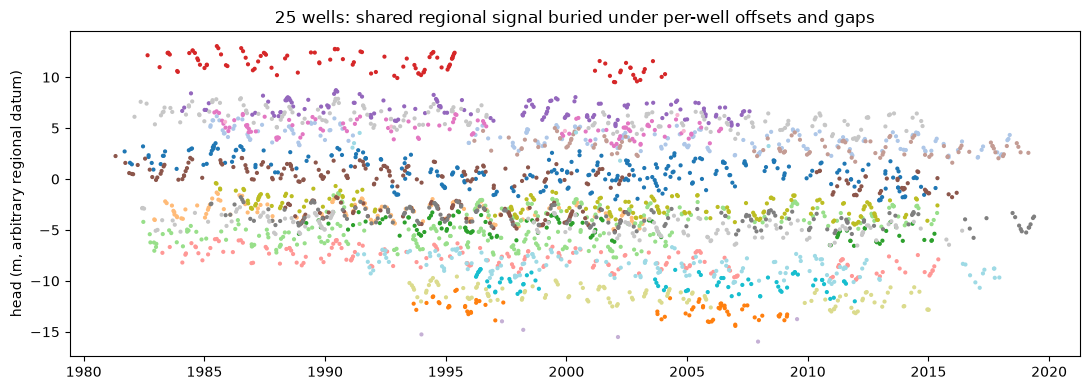

In [33]:
wells, wtruth = mlgeo_synth.well_table(seed=42)
print(f"{wells['well_id'].nunique()} wells, {len(wells)} observations, "
      f"{wells['date'].min():%Y} to {wells['date'].max():%Y}")

fig, ax = plt.subplots(figsize=(11, 4))
sc = ax.scatter(wells['date'], wells['head_m'], c=wells['well_id'], s=4, cmap='tab20')
ax.set_ylabel('head (m, arbitrary regional datum)')
ax.set_title('25 wells: shared regional signal buried under per-well offsets and gaps')
plt.tight_layout()
plt.show()

El objetivo: recuperar la señal **regional** de carga hidráulica — la tendencia y el ciclo estacional compartidos — como una serie trimestral. La jugada ingenua es `resample('QS').mean()` sobre todas las observaciones. Observe lo que hace: cada vez que un pozo con un desfase de referencia alto entra o sale del registro (y todos entran y salen en momentos distintos), la media salta una fracción de ese desfase. La «señal regional» que produce es sobre todo una historia de *qué pozos estaban siendo visitados*.

La versión consciente de los huecos hace dos movimientos:

1. **Trabajar en anomalías.** Restar primero la media propia de cada pozo, para que los desfases de referencia de escala métrica se cancelen antes de cualquier promediado. (Así es exactamente como se construyen las series de temperatura global a partir de las estaciones meteorológicas.)
2. **Ponderar por la calidad de la medición.** Cada observación lleva un `sigma_m` reportado; ponderar por $1/\sigma^2$ — el peso de varianza inversa, que minimiza la varianza de la estimación combinada — evita que una lectura de cinta de acero diluya un registro de transductor.

Las anomalías aún dejan un sesgo pequeño — cada pozo muestrea un tramo distinto del declive de 40 años, así que su propia media absorbe un segmento de tendencia ligeramente distinto —, pero ese residuo es de decímetros, no de los metros que inyectarían los desfases. Calificamos ambas versiones contra `truth["regional"]`, salvo una constante (la referencia es arbitraria, así que comparamos todas las series con sus medias removidas).

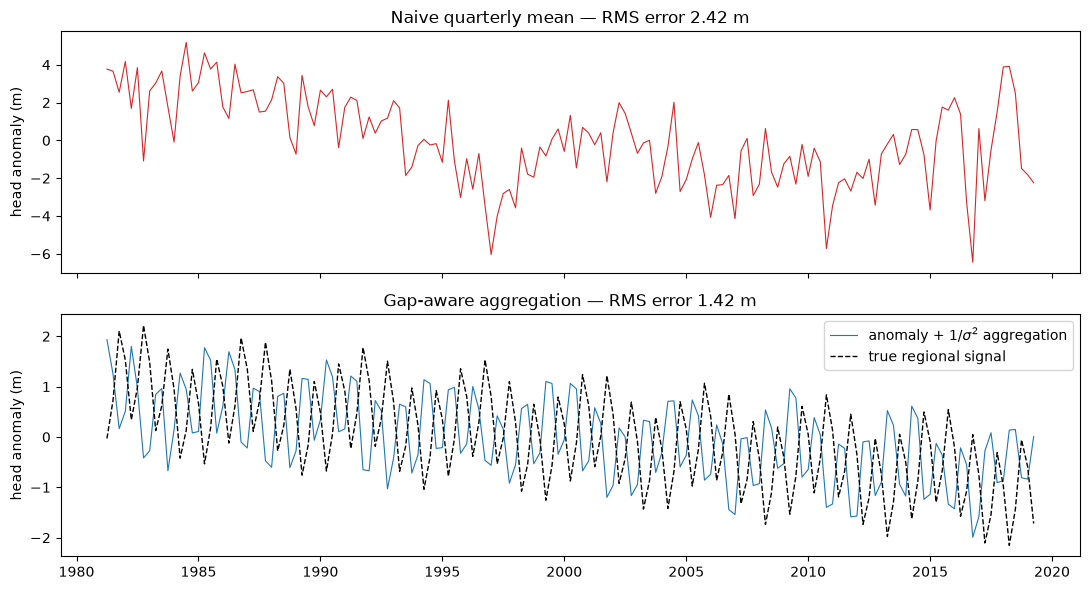

In [34]:
# Naive: average all raw heads in each quarter
naive_q = wells.set_index('date')['head_m'].resample('QS').mean()

# Gap-aware: per-well anomalies, inverse-variance weights, quarterly aggregation
w = wells.assign(
    anom_m=wells['head_m'] - wells.groupby('well_id')['head_m'].transform('mean'),
    weight=1.0 / wells['sigma_m'] ** 2,
    quarter=wells['date'].dt.to_period('Q').dt.start_time,
)
w['wx'] = w['weight'] * w['anom_m']
g = w.groupby('quarter')
aware_q = g['wx'].sum() / g['weight'].sum()

# Grade against the true regional signal (all series demeaned: the datum is arbitrary)
def rms_vs_regional(series):
    t_yr = (series.index - wells['date'].min()).days / 365.25
    reg = wtruth['regional'](t_yr)
    return np.sqrt(np.mean(((series - series.mean()) - (reg - reg.mean())) ** 2))

t_yr = (aware_q.index - wells['date'].min()).days / 365.25
regional_true = pd.Series(wtruth['regional'](t_yr), index=aware_q.index)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(naive_q - naive_q.mean(), color='tab:red', lw=0.8)
ax[0].set_title(f'Naive quarterly mean — RMS error {rms_vs_regional(naive_q):.2f} m')
ax[1].plot(aware_q - aware_q.mean(), color='tab:blue', lw=0.8,
           label=r'anomaly + 1/$\sigma^2$ aggregation')
ax[1].plot(regional_true - regional_true.mean(), 'k--', lw=1,
           label='true regional signal')
ax[1].set_title(f'Gap-aware aggregation — RMS error {rms_vs_regional(aware_q):.2f} m')
ax[1].legend()
for a in ax:
    a.set_ylabel('head anomaly (m)')
plt.tight_layout()
plt.show()

La media ingenua se equivoca por un factor de varios — saltos de escala métrica producidos enteramente por pozos que entran y salen del registro —, mientras que la serie ponderada en anomalías sigue el declive regional verdadero y su ciclo estacional hasta cerca de medio metro RMS — sobre todo el sesgo residual de segmentos de tendencia señalado arriba. No ocurrió nada sofisticado: toda la mejora vino de *negarse a promediar cosas incompatibles*. Antes de agregar cualquier flujo multisitio irregular, pregunte qué entra y sale del promedio a medida que cambia la composición, y remueva primero los niveles por sitio.

### 3.4 Cerrar el círculo: el bootstrap de bloques móviles

La sección 2.1 terminó con una advertencia: el *bootstrap* de pares dio una barra de error de velocidad tan estrecha que la velocidad *verdadera* quedaba muy afuera de ella, porque remuestrear días individuales destruye la correlación temporal del ruido GNSS, y el ruido correlacionado es exactamente lo que vuelve incierta una tendencia. La corrección es el ***bootstrap* de bloques móviles**: en lugar de remuestrear días, se remuestrean *bloques* contiguos de residuos, de modo que cada remuestra preserva la correlación del ruido hasta la longitud del bloque. Ajustamos la línea una vez, remuestreamos bloques de sus residuos, los sumamos de vuelta a la línea ajustada y reajustamos.

La longitud del bloque es — otra vez — una decisión declarada: debe superar el tiempo de correlación del ruido que le importa. Usamos 100 días, cómodamente más largo que la correlación del ruido *flicker* en los periodos que importan para una tendencia de una década; puede comprobar la sensibilidad volviendo a correr con 50 o con 200.

pair bootstrap:  std 0.019 mm/yr, true velocity sits 8.6 sigma out
block bootstrap: std 0.148 mm/yr, true velocity sits 1.1 sigma out


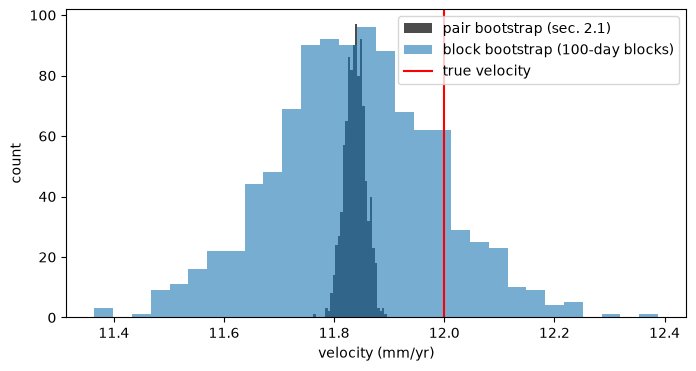

In [35]:
block = 100                     # days per block: the decision
n_blocks = int(np.ceil(n_syn / block))
line = fit.intercept + fit.slope * t_arr
resid = d_arr - line

vel_block = np.zeros(k)
for j in range(k):
    starts = rng.integers(0, n_syn - block, size=n_blocks)
    boot_resid = np.concatenate([resid[s0:s0 + block] for s0 in starts])[:n_syn]
    vel_block[j] = stats.linregress(t_arr, line + boot_resid).slope

print(f'pair bootstrap:  std {np.std(vel_syn):.3f} mm/yr, '
      f'true velocity sits {abs(fit.slope - true_velocity) / np.std(vel_syn):.1f} sigma out')
print(f'block bootstrap: std {np.std(vel_block):.3f} mm/yr, '
      f'true velocity sits {abs(fit.slope - true_velocity) / np.std(vel_block):.1f} sigma out')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vel_syn, bins=30, color='black', alpha=0.7, label='pair bootstrap (sec. 2.1)')
ax.hist(vel_block, bins=30, color='tab:blue', alpha=0.6, label=f'block bootstrap ({block}-day blocks)')
ax.axvline(true_velocity, color='red', label='true velocity')
ax.set_xlabel('velocity (mm/yr)')
ax.set_ylabel('count')
ax.legend()
plt.show()

El *bootstrap* por bloques ensancha la barra de error por un factor de aproximadamente siete — y ahora la velocidad verdadera queda a cerca de una desviación estándar de la estimación, que es como luce una barra de error honesta. Nada cambió en los datos; solo el remuestreo respetó la correlación que el ruido de verdad tiene. El histograma estrecho del *bootstrap* de pares no era conservador: estaba equivocado — y con datos reales, sin verdad de referencia que lo delatara, se habría publicado.

La misma salvedad se transfiere ahora al registro real de P395 de la sección 2.4: su barra de error de *bootstrap* de pares es una cota inferior, y un *bootstrap* por bloques sobre sus residuos es el ejercicio de seguimiento.

## 4. Ejercicio

1. **Cacería de alias.** Regenere el mareógrafo con `n_days=365` y submuestree conservando la muestra del *mediodía* en lugar de la de medianoche. ¿Cambia el periodo del alias? Explique por qué sí o por qué no a partir de la fórmula de plegado.
2. **Sensibilidad de la política de huecos.** Vuelva a correr la sección 3.2 con `max_gap_days` de 3 y de 30. Reporte el error RMS y el número de muestras rellenadas en cada caso. ¿Dónde fijaría el umbral para una estación que se mueve a 50 mm/año, y por qué?
3. **Ponderación de pozos.** En la sección 3.3, elimine los pesos $1/\sigma^2$ (media simple de las anomalías). ¿Cuánta de la mejora sobre la media ingenua sobrevive? ¿Qué le dice eso sobre cuál de los dos movimientos (anomalías, pesos) carga con el peso en esta red?
4. **Longitud de bloque.** Vuelva a correr el *bootstrap* por bloques con longitudes de bloque de 10, 50, 200 y 500 días y grafique la desviación estándar de *bootstrap* contra la longitud de bloque. Explique la tendencia en ambos extremos.